Written gds


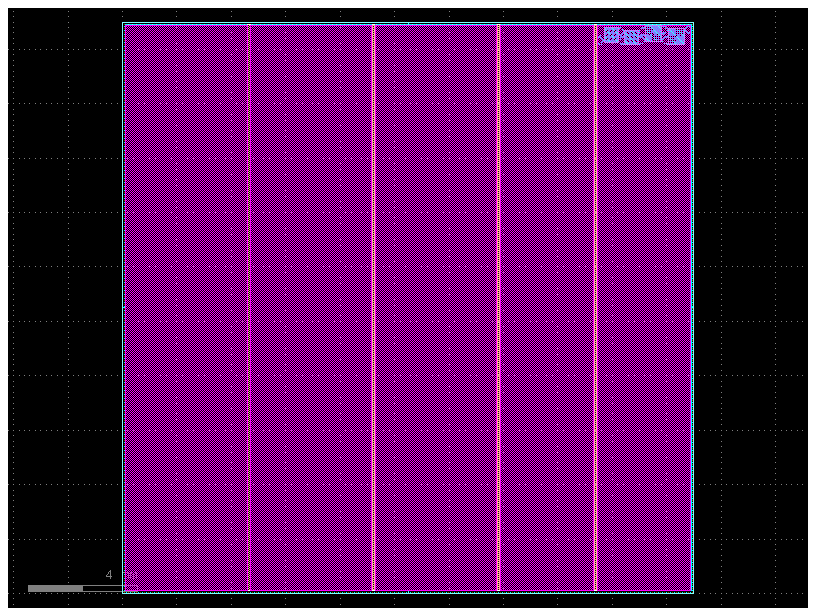

In [1]:
"""Aeluma 1 Layout

"""

import gdsfactory as gf
gf.CONF.max_cellname_length = 35
gf.gpdk.PDK.activate()

import numpy as np
import pandas as pd

from AL_Die_Frame import AL_Die_Frame
from AL_Layers import AL_Layers

from ADF_RIO import ADF_RIO

# 2D Devices
from AFQH_Device import AFQH_Device
from AQH_CB_Device import AQH_CB_Device
from AQH_Device_Rot import AQH_Device_Rot

# from OneD_Device import OneD_Device


from APF_Pulley import APF_Pulley
from SurpentineLossWg import SurpentineLossWg
# from APF_Modulated import APF_Modulated

# from DirCoupler_Device import DirCoupler_Device


###########################################################################################
# Device Configurations
###########################################################################################

ConfigFile        = "Device_Config.xlsx"
ADF_25_B1_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_25_B1")
ADF_25_B2_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_25_B2")
ADF_25_B3_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_25_B3")
ADF_25_B4_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_25_B4")
ADF_25_B5_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_25_B5")

APF_25_B1_Config     = pd.read_excel(ConfigFile, sheet_name="APF_25_B1")
APF_Pulley_25_B1_Config = pd.read_excel(ConfigFile, sheet_name="APF_Pulley_25_B1")
APF_Pulley_25_B2_Config = pd.read_excel(ConfigFile, sheet_name="APF_Pulley_25_B2")

ADF_50_B1_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_50_B1").dropna()
ADF_50_B2_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_50_B2")
ADF_50_B3_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_50_B3")
ADF_50_B4_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_50_B4")
ADF_50_B5_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_50_B5")

APF_50_B1_Config     = pd.read_excel(ConfigFile, sheet_name="APF_50_B1")

APF_Pulley_50_B1_Config = pd.read_excel(ConfigFile, sheet_name="APF_Pulley_50_B1")
APF_Pulley_50_B2_Config = pd.read_excel(ConfigFile, sheet_name="APF_Pulley_50_B2")

ADF_100_B1_Config     = pd.read_excel(ConfigFile, sheet_name="ADF_100_B1")
APF_100_B1_Config     = pd.read_excel(ConfigFile, sheet_name="APF_100_B1")
APF_Pulley_100_B1_Config = pd.read_excel(ConfigFile, sheet_name="APF_Pulley_100_B1")


# #APF_Pulley_50_Config = pd.read_excel(ConfigFile, sheet_name="APF_Pulley_50")

# #ADF_C_Config      = pd.read_excel(ConfigFile, sheet_name="ADF_C")
# DirC_Config       = pd.read_excel(ConfigFile, sheet_name="DirC")

# # AFQH_Config       = pd.read_excel(ConfigFile, sheet_name="AFQH")
# # AQH_CB_Config     = pd.read_excel(ConfigFile, sheet_name="AQH_CB")
# # AQH_Config        = pd.read_excel(ConfigFile, sheet_name="AQH")


@gf.cell
def TOP():

    Top = gf.Component()

###########################################################################################
# Die Outline and Frame
###########################################################################################
    RetLengthX    = 21000
    RetLengthY    = 21000
    NDies         = 5
    DiceLaneWidth = 100
    StreetWidth   = 10
    DieFractions = [1.1, 1.1, 1.1, 0.85,0.85]

    AL_Die_Frame_Ref = Top << AL_Die_Frame(RetLengthX=RetLengthX, RetLengthY=RetLengthY, DieFractions=DieFractions, DiceLaneWidth = DiceLaneWidth, StreetWidth=StreetWidth, CHSLayer=AL_Layers.CHS, CSLLayer=AL_Layers.CSL)

    TaperLength = 400
    
    DieWidths = AL_Die_Frame_Ref.cell.info["DieWidths"]

    # build per-die left-edge X positions, same cursor walk as the frame
    DieStartX = []
    XCursor = DiceLaneWidth
    for W in DieWidths:
        DieStartX.append(XCursor)
        XCursor += W + DiceLaneWidth

    DieLengthY = AL_Die_Frame_Ref.cell.info["DieLengthY"]
    
    TotLengthY  = RetLengthY - 2*TaperLength + 2*(StreetWidth+5)
    
###########################################################################################
# Common Parameters for 2D and 1D Devices
###########################################################################################

    BendRadius   = 25
    WgWidth      = 1.0
    WgWidthIO    = 0.7
    FArrayGap    = 30
    TotLengthX_EC  = 4468 -2*TaperLength + StreetWidth
    TotLengthX_GC  = 5200 -1*TaperLength - StreetWidth
    FArrayGapFC  = 25
    
    FArrayGapGC  = 50

    Layer        = (2,0)

    LengthSR     = 12.0
    eta          = 0.110
    
###########################################################################################
# Die 5 (Grating Couplers)  Building from top to bottom 
###########################################################################################

    #--------------------------------------------------------------------------------------
    # AFQH_GC_B1
    #--------------------------------------------------------------------------------------
    
    TotLengthX_GC = 1000
    InLengthX0    = 180

    BendRadius   = 25
    WgWidth      = 1.0
    FArrayGap    = 2*127
    AFQH_Period  = 650
    StartY = RetLengthY - DiceLaneWidth - StreetWidth - 450
    
    TwoD_Devices_StartX = DieStartX[4] + DiceLaneWidth - StreetWidth/2 
    AFQH_B1_StartX      = TwoD_Devices_StartX

    AFQH_NDevices_1 = 4

    AFQH_NxVec_1  = np.array([7,    7,      7,      7,    9,  5])
    AFQH_NyVec_1  = np.array([7,    7,      7,      7,    7, 9])
    LRingVec_1    = np.array([20,   20,     30,     30,   30, 30])
    GapVec_1      = np.array([0.30, 0.30,   0.30,   0.30, 0.30, 0.30])
    FCGapVec_1    = np.array([0.50, 0.65,   0.55,   0.65, 0.60, 0.60])

    AFQH_GC_B1: dict = {}

    for j in range(0, AFQH_NDevices_1):

            AFQH_GC_B1[f"D{j+1}"] = Top << AFQH_Device(Nx = AFQH_NxVec_1[j], Ny = AFQH_NyVec_1[j], LengthRing = int(LRingVec_1[j]), Gap = GapVec_1[j], FCGap = FCGapVec_1[j], BendRadius = BendRadius, WgWidth = WgWidth,
                                FAGap = FArrayGap, InLengthX = InLengthX0, TotLengthX = TotLengthX_GC, BendRadiusIO = BendRadius, CouplerON= 3, CouplingM = False, OutputIO = True, Euler = 1, 
                                LablePosX=0,LablePosY=-50,Layer = AL_Layers.X1P, LayerB = AL_Layers.X1B, DeviceID = "AFQH B1 "+str(j+1))

            if (j+1) % 2 == 0:                       
                AFQH_GC_B1[f"D{j+1}"].mirror_y(0)

            if j == 0:
                AFQH_GC_B1[f"D{j+1}"].move((AFQH_B1_StartX, StartY))
            else:
                AFQH_GC_B1[f"D{j+1}"].ymin = StartY - FArrayGap
                AFQH_GC_B1[f"D{j+1}"].xmin = AFQH_GC_B1[f"D{j}"].ports["DR"].center[0] - 1*InLengthX0 + 1.5*BendRadius

###########################################################################################
# return
###########################################################################################
        
    return Top

###########################################################################################
# Script entry-point
###########################################################################################
if __name__ == "__main__":
    c = TOP()
    c.write_gds("AL_Test_2.gds")
    print("Written gds")
    c.show()
    c.plot()